# Lab 8: Introducción al deep learning con PyTorch

## Sección 1. Redes multicapa con `nn.Module`

Resolver XOR con una MLP, comparar el efecto de quitar la activación y revisar los parámetros de una red multicapa.

Se trabaja en CPU con semilla 42. Los comentarios de resultados se basan en las salidas guardadas de esta ejecución.

### Preparación

Se requieren PyTorch 2.x, NumPy y Matplotlib. Si falta alguna dependencia en el kernel seleccionado, descomenta y ejecuta la siguiente celda; luego reinicia el kernel.

In [1]:
# %pip install "torch>=2,<3" numpy matplotlib

In [3]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Dispositivo: CPU")

PyTorch: 2.14.1
NumPy: 2.5.3
Dispositivo: CPU


### 1.1. Datos XOR y definición de la MLP

La red tiene dos entradas, una capa oculta de 8 neuronas con `tanh` y una salida. La salida entrega logits para `BCEWithLogitsLoss`; la probabilidad se obtiene con `sigmoid` al evaluar.

In [4]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

print(" x1  x2 | XOR")
for entrada, objetivo in zip(X, y):
    print(f" {int(entrada[0])}   {int(entrada[1])}  |  {int(objetivo.item())}")


class MLP(nn.Module):
    def __init__(self, con_activacion=True):
        super().__init__()
        self.oculta = nn.Linear(2, 8)
        self.activacion = nn.Tanh() if con_activacion else nn.Identity()
        self.salida = nn.Linear(8, 1)

    def forward(self, x):
        return self.salida(self.activacion(self.oculta(x)))


torch.manual_seed(42)
modelo_xor = MLP(con_activacion=True)
modelo_lineal = MLP(con_activacion=False)
# Ambos modelos parten de exactamente los mismos pesos y sesgos.
modelo_lineal.load_state_dict(copy.deepcopy(modelo_xor.state_dict()))
print("\nMLP con activación:\n", modelo_xor)
print("\nMLP sin activación:\n", modelo_lineal)

 x1  x2 | XOR
 0   0  |  0
 0   1  |  1
 1   0  |  1
 1   1  |  0

MLP con activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Tanh()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)

MLP sin activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Identity()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)


### 1.2. Entrenamiento y comparación

Se usa Adam con tasa 0.03 y hasta 3000 épocas. La MLP se detiene cuando clasifica correctamente las cuatro entradas y su pérdida es menor que 0.01. La versión sin activación recibe el mismo número de actualizaciones. El umbral de clasificación es 0.5.

In [5]:
def entrenar(modelo, epocas, detener_al_resolver=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.03)
    criterio = nn.BCEWithLogitsLoss()
    historial = {"perdida": [], "exactitud": []}
    modelo.train()

    for epoca in range(epocas):
        optimizador.zero_grad()
        logits = modelo(X)
        perdida = criterio(logits, y)
        perdida.backward()
        optimizador.step()

        # Registrar pérdida y exactitud después de la misma actualización.
        with torch.no_grad():
            logits_actuales = modelo(X)
            perdida_actual = criterio(logits_actuales, y).item()
            predicciones = (torch.sigmoid(logits_actuales) >= 0.5).float()
            exactitud = (predicciones == y).float().mean().item()

        historial["perdida"].append(perdida_actual)
        historial["exactitud"].append(exactitud)
        if detener_al_resolver and exactitud == 1.0 and perdida_actual < 0.01:
            break

    return historial


historial_xor = entrenar(modelo_xor, epocas=3000, detener_al_resolver=True)
historial_lineal = entrenar(modelo_lineal, epocas=len(historial_xor["perdida"]))

for nombre, historial in [("MLP con tanh", historial_xor),
                          ("MLP sin activación", historial_lineal)]:
    print(f"{nombre}: épocas={len(historial['perdida'])}, "
          f"pérdida={historial['perdida'][-1]:.6f}, "
          f"exactitud={historial['exactitud'][-1]:.0%}")

assert historial_xor["exactitud"][-1] == 1.0, "La MLP aún no resolvió XOR; revisa la ejecución."
assert historial_lineal["exactitud"][-1] < 1.0, "Revisa los datos y el modelo sin activación."

MLP con tanh: épocas=96, pérdida=0.009820, exactitud=100%
MLP sin activación: épocas=96, pérdida=0.693147, exactitud=50%


Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal
(0, 0)  |  0   |  0.004317 |     0      |   0.499901  |      0
(0, 1)  |  1   |  0.984623 |     1      |   0.499673  |      0
(1, 0)  |  1   |  0.991211 |     1      |   0.499811  |      0
(1, 1)  |  0   |  0.010572 |     0      |   0.499582  |      0


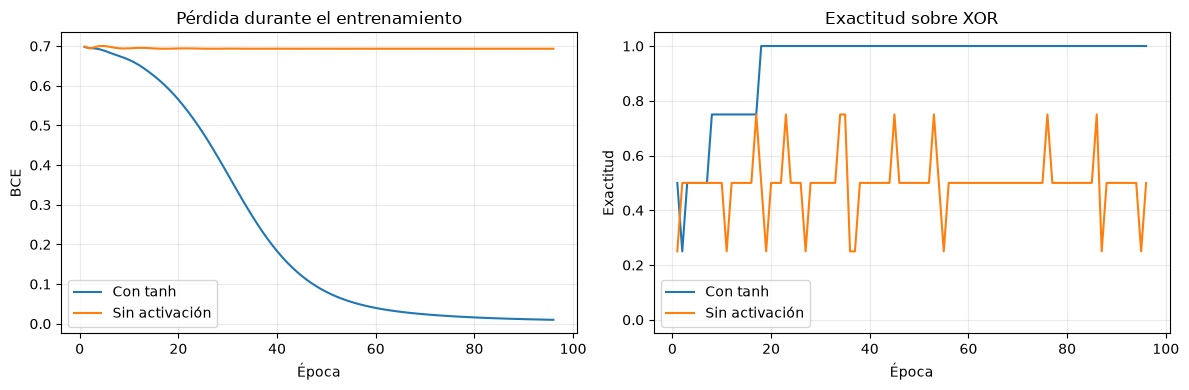

In [6]:
def evaluar(modelo):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(X)).squeeze(1)
        predicciones = (probabilidades >= 0.5).long()
    return probabilidades, predicciones


prob_xor, pred_xor = evaluar(modelo_xor)
prob_lineal, pred_lineal = evaluar(modelo_lineal)
print("Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal")
for i in range(len(X)):
    entrada = tuple(int(v) for v in X[i])
    print(f"{entrada}  |  {int(y[i].item())}   |  {prob_xor[i].item():.6f} |"
          f"     {pred_xor[i].item()}      |   {prob_lineal[i].item():.6f}  |"
          f"      {pred_lineal[i].item()}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, historial in [("Con tanh", historial_xor), ("Sin activación", historial_lineal)]:
    epocas = np.arange(1, len(historial["perdida"]) + 1)
    ejes[0].plot(epocas, historial["perdida"], label=nombre)
    ejes[1].plot(epocas, historial["exactitud"], label=nombre)
ejes[0].set(title="Pérdida durante el entrenamiento", xlabel="Época", ylabel="BCE")
ejes[1].set(title="Exactitud sobre XOR", xlabel="Época", ylabel="Exactitud", ylim=(-0.05, 1.05))
for eje in ejes:
    eje.legend()
    eje.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Resultados del entrenamiento

La MLP con `tanh` terminó el entrenamiento en **96 épocas**, con una pérdida de **0.009820** y **100% de exactitud** sobre las cuatro entradas de XOR. La gráfica muestra que alcanzó el 100% antes de terminar; las actualizaciones posteriores siguieron reduciendo la pérdida hasta cumplir el criterio de parada de menos de 0.01.

| Modelo | Épocas | Pérdida final (BCE) | Exactitud final |
|---|---:|---:|---:|
| MLP con `tanh` | 96 | 0.009820 | 100% |
| MLP sin activación oculta | 96 | 0.693147 | 50% |

Con `tanh`, las probabilidades de la clase 1 fueron **0.004317** para `(0, 0)` y **0.010572** para `(1, 1)`, mientras que para `(0, 1)` y `(1, 0)` fueron **0.984623** y **0.991211**. Por tanto, el umbral de 0.5 separa correctamente los cuatro casos y las probabilidades quedan próximas a sus etiquetas reales.

La red sin activación terminó prediciendo **0 para las cuatro entradas**, con probabilidades entre **0.499582 y 0.499901**. Solo acertó los dos casos cuya etiqueta era 0. Su pérdida de 0.693147 es aproximadamente $\ln(2)$, el valor de la entropía cruzada binaria cuando se asigna una probabilidad de 0.5. Las oscilaciones de exactitud durante el entrenamiento se explican por pequeños cambios de las probabilidades alrededor del umbral; no representan una solución estable de XOR.

Ambos modelos partieron de los mismos pesos y sesgos, utilizaron el mismo optimizador y recibieron el mismo número de actualizaciones. La diferencia observada está en la activación de la capa oculta. La exactitud reportada corresponde a los cuatro puntos usados para entrenar, que abarcan la tabla de verdad completa de XOR; no mide generalización a otros datos.

### 1.3. Fronteras de decisión

Los colores representan la probabilidad de la clase 1. La línea negra marca el umbral 0.5 y las etiquetas de los puntos muestran los valores reales de XOR.

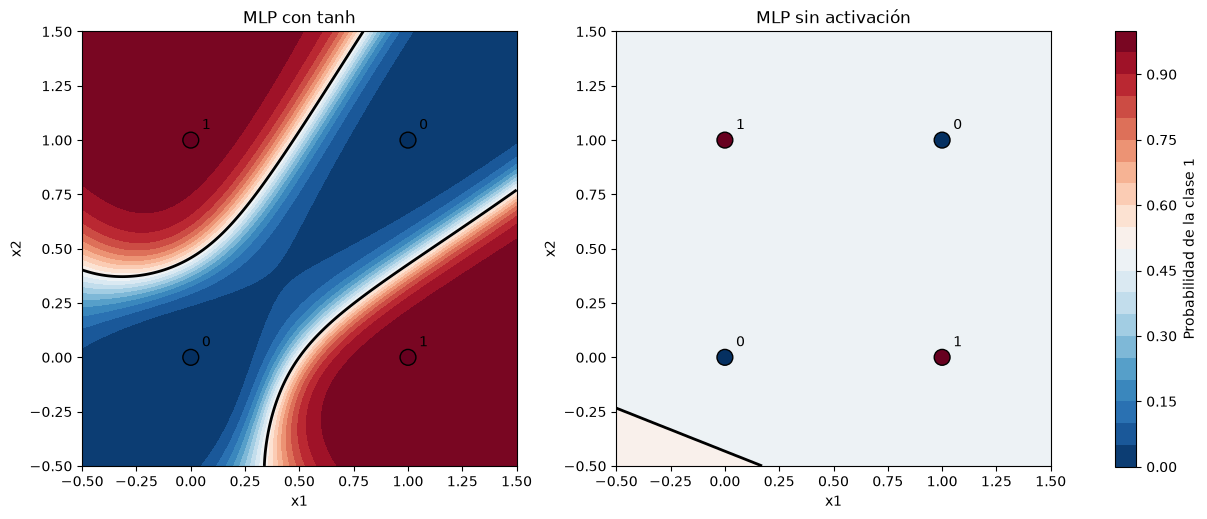

In [7]:
valores = np.linspace(-0.5, 1.5, 250)
xx, yy = np.meshgrid(valores, valores)
malla = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for eje, modelo, titulo in zip(ejes, [modelo_xor, modelo_lineal],
                               ["MLP con tanh", "MLP sin activación"]):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(malla)).numpy().reshape(xx.shape)
    fondo = eje.contourf(xx, yy, probabilidades, levels=np.linspace(0, 1, 21),
                        cmap="RdBu_r", vmin=0, vmax=1)
    if probabilidades.min() < 0.5 < probabilidades.max():
        eje.contour(xx, yy, probabilidades, levels=[0.5], colors="black", linewidths=2)
    else:
        eje.text(0.5, -0.35, "No hay cruce del umbral 0.5", ha="center", fontsize=9)
    eje.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze(1).numpy(),
                cmap="RdBu_r", vmin=0, vmax=1, edgecolors="black", s=130)
    for entrada, objetivo in zip(X, y):
        eje.annotate(str(int(objetivo.item())),
                     (entrada[0].item(), entrada[1].item()), xytext=(8, 8),
                     textcoords="offset points")
    eje.set(title=titulo, xlabel="x1", ylabel="x2", aspect="equal")
fig.colorbar(fondo, ax=ejes, label="Probabilidad de la clase 1")
plt.show()

#### Interpretación de las fronteras de decisión

La MLP con `tanh` aprendió una frontera **no lineal**: las regiones de clase 1 incluyen `(0, 1)` y `(1, 0)`, mientras que `(0, 0)` y `(1, 1)` quedan en la región de clase 0. Esta separación requiere algo más que una sola recta porque las etiquetas iguales se encuentran en esquinas opuestas.

En la red sin activación, el fondo es casi uniforme porque las probabilidades permanecen cerca de 0.5. Su frontera es una recta situada en la esquina inferior izquierda de la malla, fuera del cuadrado formado por las entradas de XOR. Así, los cuatro puntos quedan del mismo lado y reciben la clase 0. La gráfica ilustra la limitación de una frontera lineal para resolver este problema.

### 1.4. Equivalencia de las capas sin activación

Esta celda calcula los pesos y el sesgo de una única capa equivalente y compara sus logits con los de la red sin activación.

In [8]:
modelo_lineal.eval()
with torch.no_grad():
    W1, b1 = modelo_lineal.oculta.weight, modelo_lineal.oculta.bias
    W2, b2 = modelo_lineal.salida.weight, modelo_lineal.salida.bias
    W_equivalente = W2 @ W1
    b_equivalente = W2 @ b1 + b2
    logits_compuestos = modelo_lineal(malla)
    logits_equivalentes = malla @ W_equivalente.T + b_equivalente
    diferencia = (logits_compuestos - logits_equivalentes).abs().max().item()

print("W equivalente:", W_equivalente)
print("b equivalente:", b_equivalente)
print(f"Diferencia absoluta máxima en la malla: {diferencia:.10f}")
print("Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)")

W equivalente: tensor([[-0.0004, -0.0009]])
b equivalente: tensor([-0.0004])
Diferencia absoluta máxima en la malla: 0.0000000871
Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)


#### Por qué apilar capas lineales no resuelve XOR

Al eliminar la activación intermedia, la salida de la red se puede escribir como:

$$
f(x) = W_2(W_1x + b_1) + b_2
     = (W_2W_1)x + (W_2b_1 + b_2).
$$

Por tanto, las dos capas equivalen a una sola transformación afín con $W_{\mathrm{eq}} = W_2W_1$ y $b_{\mathrm{eq}} = W_2b_1 + b_2$. Aunque `nn.Linear` incluye un sesgo y es técnicamente afín, suele llamarse capa lineal. Apilar estas capas sin activaciones no añade capacidad para construir fronteras no lineales.

La diferencia absoluta máxima entre los logits de ambas expresiones fue **0.0000000871**, aproximadamente $8.71 \times 10^{-8}$. Esta pequeña discrepancia es consistente con el redondeo de las operaciones en punto flotante y respalda numéricamente la equivalencia algebraica.

Aplicar `sigmoid` al final convierte los logits en probabilidades, pero con un umbral de 0.5 la frontera sigue siendo $W_{\mathrm{eq}}x + b_{\mathrm{eq}} = 0$, una recta. En cambio, `tanh` entre las capas impide reducir toda la composición a una sola transformación afín. La combinación de la capa oculta y esa activación permite resolver XOR.

### 1.5. Red de la diapositiva: 3 → 4 → 4 → 2

Construir la arquitectura y recorrer `named_parameters()` para mostrar la forma y cantidad de elementos de cada tensor de pesos y sesgos.

In [9]:
class RedMulticapa(nn.Module):
    def __init__(self):
        super().__init__()
        self.oculta1 = nn.Linear(3, 4)
        self.oculta2 = nn.Linear(4, 4)
        self.salida = nn.Linear(4, 2)
        self.activacion = nn.Tanh()

    def forward(self, x):
        x = self.activacion(self.oculta1(x))
        x = self.activacion(self.oculta2(x))
        return self.salida(x)


torch.manual_seed(42)
model = RedMulticapa()
print(model)
print(f"\n{'Tensor':<22} {'Forma':<15} {'Parámetros':>10}")
for nombre, parametro in model.named_parameters():
    print(f"{nombre:<22} {str(tuple(parametro.shape)):<15} {parametro.numel():>10}")

total_parametros = sum(p.numel() for p in model.parameters())
total_manual = (3 * 4 + 4) + (4 * 4 + 4) + (4 * 2 + 2)
print(f"\nTotal con PyTorch: {total_parametros}")
print(f"Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = {total_manual}")
assert total_parametros == total_manual == 46
print("Forma de salida para un ejemplo:", tuple(model(torch.zeros(1, 3)).shape))

RedMulticapa(
  (oculta1): Linear(in_features=3, out_features=4, bias=True)
  (oculta2): Linear(in_features=4, out_features=4, bias=True)
  (salida): Linear(in_features=4, out_features=2, bias=True)
  (activacion): Tanh()
)

Tensor                 Forma           Parámetros
oculta1.weight         (4, 3)                  12
oculta1.bias           (4,)                     4
oculta2.weight         (4, 4)                  16
oculta2.bias           (4,)                     4
salida.weight          (2, 4)                   8
salida.bias            (2,)                     2

Total con PyTorch: 46
Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = 46
Forma de salida para un ejemplo: (1, 2)


#### Parámetros de la red 3 → 4 → 4 → 2

La red tiene **46 parámetros entrenables**: **36 pesos** y **10 sesgos**. En `nn.Linear`, la matriz de pesos tiene forma `(neuronas de salida, neuronas de entrada)` y el vector de sesgos contiene un elemento por neurona de salida.

| Tensor | Forma | Cantidad |
|---|---|---:|
| `oculta1.weight` | `(4, 3)` | 12 |
| `oculta1.bias` | `(4,)` | 4 |
| `oculta2.weight` | `(4, 4)` | 16 |
| `oculta2.bias` | `(4,)` | 4 |
| `salida.weight` | `(2, 4)` | 8 |
| `salida.bias` | `(2,)` | 2 |
| **Total** | | **46** |

El conteo obtenido con `named_parameters()` coincide con el cálculo manual: **(3 × 4 + 4) + (4 × 4 + 4) + (4 × 2 + 2) = 46**. Las activaciones `tanh` no agregan parámetros entrenables. Para un lote de un ejemplo con tres características, la salida tiene forma **(1, 2)**, como corresponde a las dos neuronas de salida. Esta red se construyó para verificar la arquitectura y contar sus parámetros; el entrenamiento de XOR utilizó la MLP de dos entradas.

## Sección 2. Funciones de activación

Comparar sigmoide, `tanh` y ReLU sobre el intervalo [-5, 5], calcular sus derivadas con `autograd` y presentar las funciones y derivadas en una figura con dos paneles. La interpretación se basa en las gráficas y los valores guardados de esta ejecución.

In [1]:
import torch
import matplotlib.pyplot as plt

z = torch.linspace(-5, 5, 200, requires_grad=True)

activaciones = {
    "Sigmoide": torch.sigmoid(z),
    "tanh": torch.tanh(z),
    "ReLU": torch.relu(z),
}

derivadas = {
    nombre: torch.autograd.grad(salida.sum(), z)[0]
    for nombre, salida in activaciones.items()
}

print(f"Tensor z: {z.numel()} puntos entre {z[0].item():.1f} y {z[-1].item():.1f}")
print("requires_grad:", z.requires_grad)
print("Derivadas calculadas con torch.autograd.grad:", ", ".join(derivadas))

Tensor z: 200 puntos entre -5.0 y 5.0
requires_grad: True
Derivadas calculadas con torch.autograd.grad: Sigmoide, tanh, ReLU


### 2.1. Funciones y derivadas

Se mantiene el mismo color para cada función en ambos paneles. Las líneas de referencia marcan los ejes y facilitan comparar las regiones donde la derivada se acerca a cero.

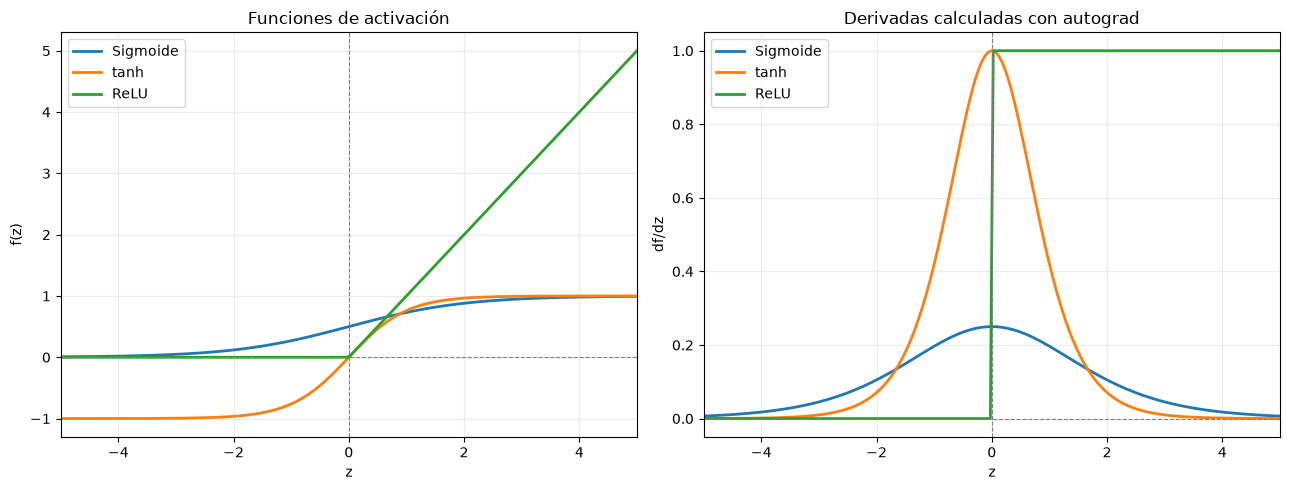

In [2]:
z_grafico = z.detach().numpy()
colores = {"Sigmoide": "tab:blue", "tanh": "tab:orange", "ReLU": "tab:green"}
fig, ejes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for nombre in activaciones:
    ejes[0].plot(z_grafico, activaciones[nombre].detach().numpy(),
                 label=nombre, color=colores[nombre], linewidth=2)
    ejes[1].plot(z_grafico, derivadas[nombre].detach().numpy(),
                 label=nombre, color=colores[nombre], linewidth=2)

ejes[0].set(title="Funciones de activación", xlabel="z", ylabel="f(z)")
ejes[1].set(title="Derivadas calculadas con autograd", xlabel="z", ylabel="df/dz")
for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    eje.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    eje.set_xlim(-5, 5)
    eje.grid(alpha=0.25)
    eje.legend()
plt.tight_layout()
plt.show()

#### Interpretación de las funciones y sus derivadas

La gráfica muestra que la **sigmoide** produce valores entre 0 y 1 y se aplana hacia ambos extremos del intervalo. **`tanh`** produce valores entre -1 y 1, pasa por el origen y también se aplana para entradas de gran magnitud. **ReLU** devuelve cero para entradas negativas y crece linealmente para entradas positivas.

En el panel de derivadas, sigmoide y `tanh` tienen su mayor pendiente cerca de cero y derivadas cercanas a cero en los extremos. Esto corresponde a sus regiones de **saturación**: modificar la entrada produce muy poco cambio en la salida. ReLU presenta una derivada de 0 para $z < 0$ y de 1 para $z > 0$, por lo que su parte positiva no se satura.

Las derivadas se obtuvieron con `torch.autograd.grad` sobre un tensor de **200 puntos entre -5 y 5**, con `requires_grad=True`. Como cada salida depende únicamente de la entrada en su misma posición, derivar la suma de las salidas permite obtener las derivadas elemento a elemento.

### 2.2. Valores de referencia para interpretar las gráficas

Calcular también las derivadas en puntos específicos permite comparar el centro y los extremos del intervalo. La malla de 200 puntos no incluye exactamente cero, por lo que se evalúa por separado. ReLU no tiene derivada clásica en cero; el valor que devuelve autograd allí corresponde a la convención de PyTorch.

In [3]:
z_referencia = torch.tensor([-5., -2., -1., 0., 1., 2., 5.], requires_grad=True)
funciones_referencia = {
    "Sigmoide": torch.sigmoid,
    "tanh": torch.tanh,
    "ReLU": torch.relu,
}
derivadas_referencia = {}
for nombre, funcion in funciones_referencia.items():
    salida = funcion(z_referencia)
    derivadas_referencia[nombre] = torch.autograd.grad(salida.sum(), z_referencia)[0]

print(f"{'z':>6} {'Deriv. sigmoide':>18} {'Deriv. tanh':>16} {'Deriv. ReLU':>16}")
for i, valor in enumerate(z_referencia.detach().tolist()):
    print(f"{valor:6.1f}"
          f" {derivadas_referencia['Sigmoide'][i].item():18.6f}"
          f" {derivadas_referencia['tanh'][i].item():16.6f}"
          f" {derivadas_referencia['ReLU'][i].item():16.6f}")

     z    Deriv. sigmoide      Deriv. tanh      Deriv. ReLU
  -5.0           0.006648         0.000182         0.000000
  -2.0           0.104994         0.070651         0.000000
  -1.0           0.196612         0.419974         0.000000
   0.0           0.250000         1.000000         0.000000
   1.0           0.196612         0.419974         1.000000
   2.0           0.104994         0.070651         1.000000
   5.0           0.006648         0.000182         1.000000


#### Regiones donde se desvanece el gradiente

Los valores calculados confirman el comportamiento de las curvas:

| Punto de evaluación | Derivada de sigmoide | Derivada de `tanh` | Derivada de ReLU |
|---|---:|---:|---:|
| $z=-5$ | 0.006648 | 0.000182 | 0 |
| $z=0$ | 0.250000 | 1.000000 | 0 |
| $z=5$ | 0.006648 | 0.000182 | 1 |

La **sigmoide** tiene una derivada máxima de **0.25** en cero, pero en $z=\pm5$ disminuye a **0.006648**. Por tanto, el gradiente se atenúa especialmente para entradas muy negativas o muy positivas, cuando la salida está cerca de 0 o de 1.

En **`tanh`**, la derivada en cero es **1**, lo que permite transmitir mejor el gradiente local cerca del origen. Sin embargo, también se satura en ambos extremos: en $z=\pm5$ su derivada es apenas **0.000182**. Para esas entradas, su derivada es incluso menor que la de la sigmoide; usar `tanh` no elimina el problema de saturación.

Durante la retropropagación se multiplican las derivadas locales y los pesos de las capas por la regla de la cadena. Si varias activaciones aportan factores muy pequeños, el gradiente que llega a las primeras capas puede reducirse considerablemente y dificultar su aprendizaje. Estas gráficas ilustran ese mecanismo local; aquí no se entrenó una red profunda para medirlo directamente.

#### ¿Por qué ReLU es una opción habitual en capas ocultas?

Para entradas positivas, **ReLU mantiene una derivada de 1**, como muestran los valores en $z=1$, $z=2$ y $z=5$. En esa región, la activación no reduce el gradiente local ni se satura al aumentar la entrada. Además, su cálculo es sencillo: $\operatorname{ReLU}(z)=\max(0,z)$. Estas propiedades la hacen una elección habitual para capas ocultas y ayudan a entrenar redes profundas.

Su limitación aparece en la región negativa, donde la salida y la derivada son cero. Si una neurona permanece en esa región para todos los ejemplos, puede dejar de recibir actualizaciones útiles a través de esa activación, fenómeno conocido como **neurona muerta**. Por ello, ReLU no garantiza por sí sola que desaparezcan todos los problemas de gradientes.

En **$z=0$**, ReLU no tiene derivada clásica porque las pendientes de sus dos lados son distintas. La tabla muestra que PyTorch utiliza **0** en ese punto como convención para autograd. El segmento que conecta las derivadas 0 y 1 en la gráfica es un efecto de unir los puntos muestreados; no significa que la derivada de ReLU cambie de forma gradual cerca de cero.